# LoRA Fine-Tuning on Tiny Shakespeare

Demonstration of Low-Rank Adaptation (LoRA) applied to GPT-2 small,
fine-tuned on the Tiny Shakespeare corpus.

## Prerequisites

- Run this notebook with the **repository root** (the directory containing `main.py`) as the working directory.
- This notebook loads `checkpoints/checkpoint_epoch_3.pt` and `outputs/training_history.png`. Both are produced by training, not shipped in the repo (`checkpoints/` is gitignored). If you don't have them yet, run `python main.py train` first (~3 epochs, CPU — see the main README for expected timing).

In [1]:
from pathlib import Path

from IPython.display import Image

from train.config import TrainingConfig
from evaluate.evaluator import Evaluator

if not Path("main.py").exists():
    raise RuntimeError(
        "Working directory must be the repository root (the directory "
        "containing main.py). Restart the kernel there, or run "
        "`%cd path/to/lora-finetune` first."
    )

## Training History

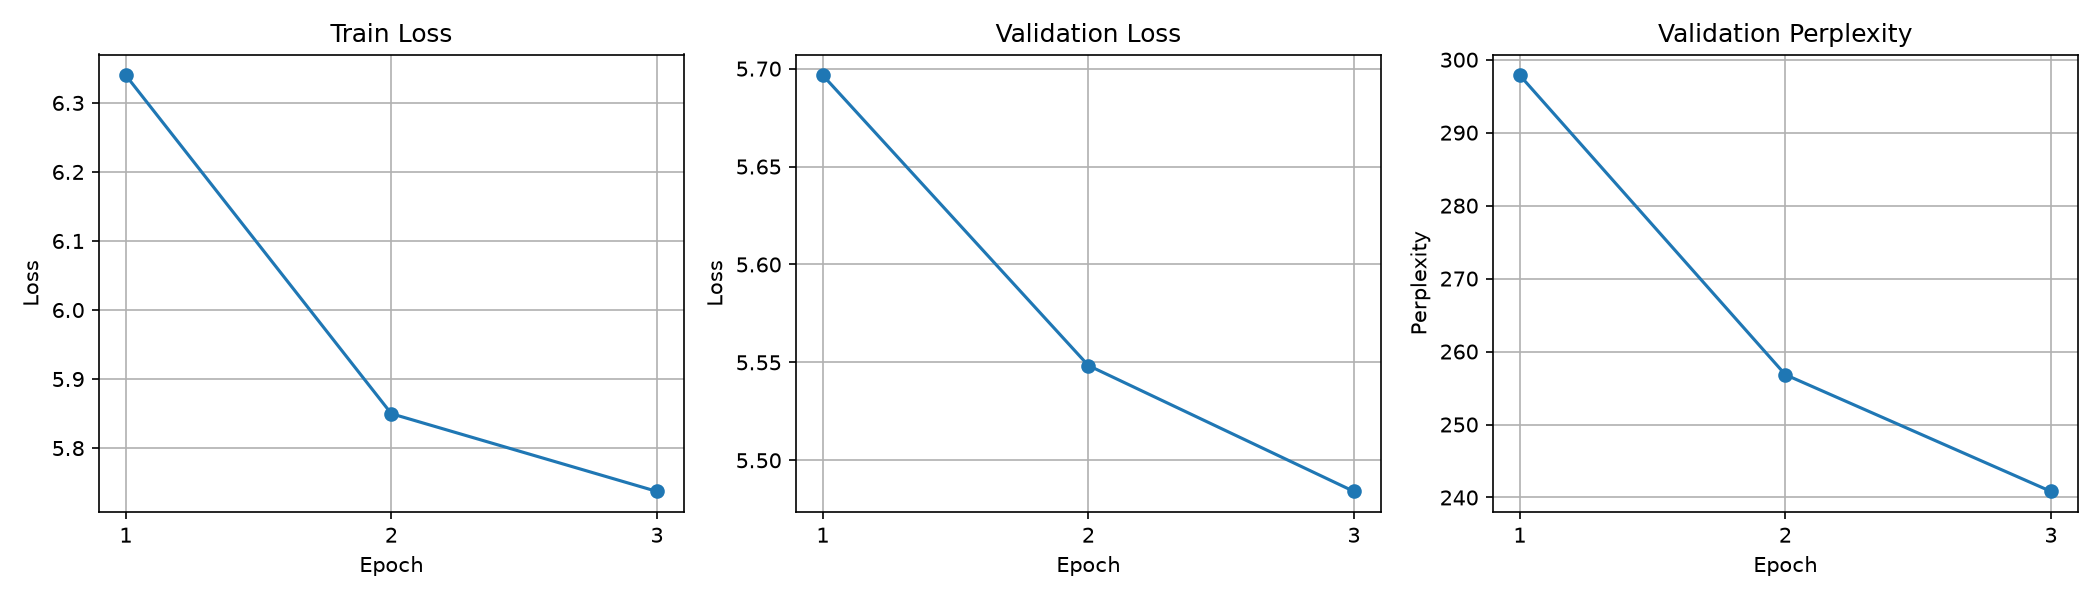

In [2]:
Image(filename="outputs/training_history.png")

## Perplexity Comparison

In [3]:
config = TrainingConfig()
evaluator = Evaluator(config, checkpoint_path="checkpoints/checkpoint_epoch_3.pt")
perplexity_results = evaluator.compare_perplexity()
perplexity_results

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (36059 > 1024). Running this sequence through the model will result in indexing errors


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Perplexity comparison (validation set)
Model          Perplexity
--------------------------------------------
Base           10157.3655
Finetuned        240.8267


{'base': 10157.365463770482, 'finetuned': 240.8266545875653}

## Text Generation: Base vs Fine-Tuned

In [4]:
prompts = [
    "To be or not to be",
    "Shall I compare thee",
    "What light through yonder window",
]
evaluator.compare_generation(prompts=prompts)


Prompt 1
Prompt:
To be or not to be

--- Base model ---
To be or not to be, the world is filled with people who are so stupid, so arrogant, so arrogant to the point of being as if they could make out every single person on the planet in a single moment.

We all have to deal with that.

It's not that we can't cope with our own stupidity, it's that even if we have a good grasp of what's going on in the world, there's no point in making any effort to think about it in the best possible way.

The world needs to understand that they are stupid, that they aren't truly human,

--- Fine-tuned model ---
To be or not to be
 this
 will in a in our?I you speak for
 that if are you speak
 my, you speak for
 I
 your, speak for
 my and words
 your and words the
 are for you
 what. not I speak words
 and speak you?
P:Not be I
 I not the answer to the I
 are, you speak I
 my; you speak answer not
 answer I you.
DENIE
, you answer;
 speak not, nor you you
 I
 you. is you do that a
 speak the?




Prompt 2
Prompt:
Shall I compare thee

--- Base model ---
Shall I compare thee to thyself?

But shall he who takes his vow do it?

And who shall take his vow?

He who takes his vow shall never take it

And who shall take his vow shall never take it

And who shall take his vow shall never take it

And who shall take his vow shall never take it

And who shall take his vow shall never take it

And who shall take his vow shall never take it

And who shall take his vow shall never take it

And who shall take his vow shall never take it

--- Fine-tuned model ---
Shall I compare thee with the
 of of of;
 thou with theof thy,I with of
 that: the I the to that I to
 this thee not thou,:This it
 a with; with thou, thyself
 the; thy, thy, thy, thy.
R, is I the, thee, thy;, thy, thy
 what not thou my, thy, thou
 is my; thou my I.I I all thy thy,And thou not but me
 thy be
 is. thee the, me my,, thy
 what be you? thou,



Prompt 3
Prompt:
What light through yonder window

--- Base model ---
What light through yonder window was not shining. It was the light of God, whose light, it was.

I am a young woman, a young woman's daughter. I am going to stay in heaven, and I am going to stay in heaven. I am going to stay in heaven. I'm going to stay in heaven. I'm going to stay in heaven.

My first job was a job at a fast food restaurant. We were doing a lot of things in that restaurant, but then I realized what was going on in my life. I realized that my wife and I are going to the

--- Fine-tuned model ---
What light through yonder window
 see the,,, and you
, and are my.
ISONUS:And you!
ISUS:I my!, my,!, a,,,, of, I is as,, the,
 the
 I; not my. but, the.
OURUS
,,,, it the for,., it you I, my, my, that
 I, the. do
ASUS
 I! me, a, of
,, I, I my, I like the of, and
 the of it it


## Conclusion

LoRA fine-tuning reduced perplexity from ~10,157 (base GPT-2) to ~241
on the Shakespeare validation set — a 42x improvement — while training
only 0.12% of the model parameters (147,456 out of 124M).